Logic of the project:

1.   Get the data from Binance through API (binance.client)
2.   Add financial indicators (SMA, EMA, ROC etc.) to the dataset. 
3.   Check how each model perform on the data based on one ticker
4.   Pick model and apply it to all others tickers. 

Important note: I am ignoring model accuracy. Model selected based on revenue and nr of deals made. 


# Installing dependencies

In [1]:
# I am using Binance API to get the data
try:
  from binance.client import Client
except:
  !python3 -m pip install python-binance
  from binance.client import Client

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 65 kB 2.5 MB/s 
     |████████████████████████████████| 290 kB 10.7 MB/s 
     |████████████████████████████████| 106 kB 56.0 MB/s 
     |████████████████████████████████| 45 kB 3.4 MB/s 
     |████████████████████████████████| 749 kB 29.8 MB/s 
  Attempting uninstall: regex
    Found existing installation: regex 2022.6.2
    Uninstalling regex-2022.6.2:
      Successfully uninstalled regex-2022.6.2


In [2]:
try:
  from catboost import CatBoostClassifier
except:
  !python3 -m pip install catboost
  from catboost import CatBoostClassifier

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 1.2 MB/s 


In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.decomposition import PCA

In [4]:
import pandas as pd
import numpy as np

try:
  import bottleneck as bn
except:
  !python3 -m pip install bottleneck
  import bottleneck as bn
import random
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Teach me how handle the the warnings :) . But until then:
from google.colab import drive

import warnings
warnings.filterwarnings('ignore')

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 355 kB 4.8 MB/s 


# Variables

In [7]:
# Binance API
apikey = 
secret = 

commission=0.001

# select period for gathering data about selected currency. This data will be used in training and verrifing the model
start_date = '2021-02-01'
end_date = '2022-01-01'

train_date_start = '2021-07-01'
train_date_end = '2021-07-30'

verif_date_start = '2021-10-03'
verif_date_end = '2021-10-27'
recent_date_start = '2021-10-27'
recent_date_end= '2021-12-15'

# periods of time for making a deals(creation of possitions). If short>long -> buy, otherwise -> sell
short_window = 
long_window = 

nr_of_random_iter = 2000 # nr of itterations to select random number of columns in dataset

# select a period to really understand if i did everything good. 
now_start_date = '2022-03-20'
now_end_date = '2022-06-30'

# models to test
classifiers = [
    KNeighborsClassifier(2),
    KNeighborsClassifier(10),
    DecisionTreeClassifier(max_depth=20),
    DecisionTreeClassifier(max_depth=40),
    LinearDiscriminantAnalysis(),
    GaussianNB()
    #SVC()
    #CatBoostClassifier(silent=True)

]

tickers = ['ADA','BEAM', 'BNB', 'BAT', 'BTC', 'COTI', 'EOS', 'ETH', 'SOL', 'VET', 'XLM', 'XMR', 'XRP',
            'AVAX', 'DOT', 'FTM', 'LINK', 'LTC', 'MATIC', 'TRX']

# Binance API

I am getting the data for each crypto from Binance via API.
Input:

*   ticker - any crypto pair, like BTCUSDT 

*   date_from - start period dd/mm/yyyy, like 02.10.2021 

*   [date_end] - end period dd/mm/yyyy, like 10.10.2021

*   [print_falg] - boolian. Will print confirmation that data was downloaded


Output:
df






  
     

   

In [8]:
client = Client(apikey, secret)


def binance_data(ticker, date_from, date_end="", print_falg=False ):
    hist_df = pd.DataFrame()
    # https://python-binance.readthedocs.io/en/latest/binance.html#binance.client.BaseClient.KLINE_INTERVAL_1DAY - examples of all available time ranges to download
    while len(hist_df) < 1:
        try:
            if date_end: historical = client.get_historical_klines(ticker, Client.KLINE_INTERVAL_1HOUR, date_from, date_end)
            else: historical = client.get_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, date_from)
            hist_df = pd.DataFrame(historical)
        except:
            print('Wasnt able to download the data for ', ticker)
            time.sleep(20)
            continue
    
    hist_df.columns = ['Open Time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close Time', 'Quote Asset Volume',
                       'Number of Trades', 'TB Base Volume', 'TB Quote Volume', 'Ignore']

    hist_df.drop(['Open Time', 'Quote Asset Volume',
                  'Number of Trades', 'TB Base Volume', 'TB Quote Volume', 'Ignore'], axis=1, inplace=True)

    hist_df['Close Time'] = pd.to_datetime(hist_df['Close Time'] / 1000, unit='s')
    hist_df.set_index(hist_df['Close Time'], inplace=True)

    numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

    hist_df[numeric_columns] = hist_df[numeric_columns].apply(pd.to_numeric, axis=1)
    if print_falg: print("Data loaded", ticker, date_from)
    return hist_df

# Data Preprocessing

In [9]:
def SMA(price_date, time_period):
    # Simple moving average, which we will refer to as SMA, is a basic technical analysis indicator. 
    # The simple moving average, as you may have guessed from its name, is computed by adding up the price of an instrument over a certain period of time divided by the number of time periods. 
    # It is basically the price average over a certain time period, with equal weight being used for each price. 
    # The time period over which it is averaged is often referred to as the lookback period or history.

    # SMA = ( Sum ( Price, n ) ) / n
    # Where: n = Time Period

    return bn.move_mean(price_date, window=time_period)

def ROC(df, n):
    M = df.diff(n - 1)
    N = df.shift(n - 1)
    ROC = pd.Series(((M / N) * 100), name='ROC_' + str(n))
    return ROC

def EMA(price_date, time_period):
    # The EMA is similar to the simple moving average, but, instead of weighing all prices in the history equally, 
    # it places more weight on the most recent price observation and less weight on the older price observations. 
    # This is endeavoring to capture the intuitive idea that the new price observation has more up-to-date information than prices in the past. 
    # It is also possible to place more weight on older price observations and less weight on the newer price observations. 
    # This would try to capture the idea that longer-term trends have more information than short-term volatile price movements.

    # EMA = ( P - EMAp ) * K + EMAp
    # Where: P = Price for the current period EMAp = the Exponential moving Average for the previous period K = the smoothing constant, 
    # equal to 2 / (n + 1) n = the number of periods in a simple moving average roughly approximated by the EMA

    alpha = 2 / (time_period + 1.0)
    n = price_date.shape[0]
    scale_arr = (1 - alpha) ** (-1 * np.arange(n))
    weights = (1 - alpha) ** np.arange(n)
    pw0 = (1 - alpha) ** (n - 1)
    mult = price_date * pw0 * scale_arr
    cumsums = mult.cumsum()
    return cumsums * scale_arr[::-1] / weights.cumsum()



def APO(ema_fast=None, ema_slow=None):
    # The absolute price oscillator, which we will refer to as APO, is a class of indicators that builds on top of moving averages of prices to capture specific short-term deviations in prices. 
    # The absolute price oscillator is computed by finding the difference between a fast exponential moving average and a slow exponential moving average.

    # APO = Fast Exponential Moving Average - Slow Exponential Moving Average

    return np.subtract(ema_fast, ema_slow)



def MACD(sma_slow=None, sma_fast=None):
    # The Moving Average Convergence Divergence (MACD) was developed by Gerald Appel, and is based on the differences between two moving averages of different lengths, 
    # a Fast and a Slow moving average. A second line, called the Signal line is plotted as a moving average of the MACD. 
    # A third line, called the MACD Histogram is optionally plotted as a histogram of the difference between the MACD and the Signal Line. 
    
    # MACD = FastMA - SlowMA

    return np.subtract(sma_fast, sma_slow)


def BolBands(price_data, time_period, stdev_factor=2):
    # The Bollinger Band (BBANDS) study created by John Bollinger plots upper and lower envelope bands around the price of the instrument. 
    # The width of the bands is based on the standard deviation of the closing prices from a moving average of price.

    # Middle Band = n-period moving average
    # Upper Band = Middle Band + ( y * n-period standard deviation)
    # Lower Band = Middle Band - ( y * n-period standard deviation)
    # Where: n = number of periods y = factor to apply to the standard deviation value, (typical default for y = 2)
 
    sma_values = SMA(price_data, time_period)
    return sma_values + stdev_factor * np.std(price_data), sma_values - stdev_factor * np.std(price_data)



def RSI(price_data, time_period = 10):
    # It comprises a lookback period, which it uses to compute the magnitude of the average of gains/price increases over that period, 
    # as well as the magnitude of the averages of losses/price decreases over that period. 
    # Then, it computes the RSI value that normalizes the signal value to stay between 0 and 100, 
    # and attempts to capture if there have been many more gains relative to the losses, or if there have been many more losses relative to the gains. 
    # RSI values over 50% indicate an uptrend, while RSI values below 50% indicate a downtrend.

    def calc_rsi(array, deltas, avg_gain, avg_loss, n):

        # Use Wilder smoothing method
        up = lambda x: x if x > 0 else 0
        down = lambda x: -x if x < 0 else 0
        i = n + 1
        for d in deltas[n + 1:]:
            avg_gain = ((avg_gain * (n - 1)) + up(d)) / n
            avg_loss = ((avg_loss * (n - 1)) + down(d)) / n
            if avg_loss != 0:
                rs = avg_gain / avg_loss
                array[i] = 100 - (100 / (1 + rs))
            else:
                array[i] = 100
            i += 1

        return array

    def get_rsi(array, n):

        deltas = np.append([0], np.diff(array))

        avg_gain = np.sum(deltas[1:n + 1].clip(min=0)) / n
        avg_loss = -np.sum(deltas[1:n + 1].clip(max=0)) / n

        array = np.empty(deltas.shape[0])
        array.fill(np.nan)

        return calc_rsi(array, deltas, avg_gain, avg_loss, n)

    return get_rsi(price_data, n=time_period)

def MOM(df, n):
    # momentum is simply the difference between the current price and price of some fixed time periods in the past. 
    # Consecutive periods of positive momentum values indicate an uptrend; conversely, if momentum is consecutively negative, that indicates a downtrend. 
    # Often, we use simple/exponential moving averages of the MOM indicator

    MOM = pd.Series(df.diff(n), name='Momentum_' + str(n))
    return MOM    
    
def STOK(close, low, high, n):
    STOK = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
    return STOK


def STOD(close, low, high, n):
    STOK = ((close - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min())) * 100
    STOD = STOK.rolling(3).mean()
    return STOD


In [10]:
def add_indicators(dataset):

    dataset['ROC10'] = ROC(dataset['Close'], 10)
    dataset['ROC30'] = ROC(dataset['Close'], 30)
    dataset['ROC50'] = ROC(dataset['Close'], 50)
    dataset['ROC100'] = ROC(dataset['Close'], 100)
    dataset['ROC150'] = ROC(dataset['Close'], 150)

    dataset['MOM10'] = MOM(dataset['Close'], 10)
    dataset['MOM30'] = MOM(dataset['Close'], 30)
    dataset['MOM50'] = MOM(dataset['Close'], 50)
    dataset['MOM100'] = MOM(dataset['Close'], 100)
    dataset['MOM150'] = MOM(dataset['Close'], 150)

    # calculation of relative strength index
    dataset['RSI10'] = RSI(dataset['Close'], 10)
    dataset['RSI30'] = RSI(dataset['Close'], 30)
    dataset['RSI50'] = RSI(dataset['Close'], 50)
    dataset['RSI100'] = RSI(dataset['Close'], 100)
    dataset['RSI200'] = RSI(dataset['Close'], 200)

    dataset['%K10'] = STOK(dataset['Close'], dataset['Low'], dataset['High'], 10)
    dataset['%D10'] = STOD(dataset['Close'], dataset['Low'], dataset['High'], 10)
    dataset['%K30'] = STOK(dataset['Close'], dataset['Low'], dataset['High'], 30)
    dataset['%D30'] = STOD(dataset['Close'], dataset['Low'], dataset['High'], 30)

    dataset['%K50'] = STOK(dataset['Close'], dataset['Low'], dataset['High'], 50)
    dataset['%D50'] = STOD(dataset['Close'], dataset['Low'], dataset['High'], 50)
    dataset['%K90'] = STOK(dataset['Close'], dataset['Low'], dataset['High'], 90)
    dataset['%D90'] = STOD(dataset['Close'], dataset['Low'], dataset['High'], 90)

    dataset['%K200'] = STOK(dataset['Close'], dataset['Low'], dataset['High'], 200)
    dataset['%D200'] = STOD(dataset['Close'], dataset['Low'], dataset['High'], 200)

    # Calculation of moving average

    dataset['SMA10'] = SMA(dataset['Close'], 10) / dataset['Close']
    dataset['SMA20'] = SMA(dataset['Close'], 20) / dataset['Close']
    dataset['SMA55'] = SMA(dataset['Close'], 55) / dataset['Close']
    dataset['SMA90'] = SMA(dataset['Close'], 90) / dataset['Close']
    dataset['SMA155'] = SMA(dataset['Close'], 155) / dataset['Close']

    dataset['MACD1020'] = MACD(dataset['SMA10'], dataset['SMA20'])
    dataset['MACD2055'] = MACD(dataset['SMA20'], dataset['SMA55'])
    dataset['MACD5590'] = MACD(dataset['SMA55'], dataset['SMA90'])
    dataset['MACD90155'] = MACD(dataset['SMA90'], dataset['SMA155'])

    dataset['BolBands10up'], dataset['BolBands10down'] = BolBands(dataset['Close'], 10)
    dataset['BolBands20up'], dataset['BolBands20down'] = BolBands(dataset['Close'], 20)
    dataset['BolBands50up'], dataset['BolBands50down'] = BolBands(dataset['Close'], 50)
    dataset['BolBands100up'], dataset['BolBands100down'] = BolBands(dataset['Close'], 100)


    # calculation of exponential moving average
    dataset['EMA20'] = EMA(dataset['Close'], 20) / dataset['Close']
    dataset['EMA100'] = EMA(dataset['Close'], 100) / dataset['Close']
    
    dataset['APO'] = APO(dataset['EMA20'], dataset['EMA100'])
    dataset['Low'] = dataset['Low'] / dataset['Close']
    dataset['High'] = dataset['High'] / dataset['Close']
    dataset['Open'] = dataset['Open'] / dataset['Close']

    #dataset['eth_change1'] = eth_data['Close'].pct_change(periods=1)
    # dataset['eth_change3'] = eth_data['Close'].pct_change(periods=3)
    # dataset['eth_change5'] = eth_data['Close'].pct_change(periods=5)
    # dataset['eth_change10'] = eth_data['Close'].pct_change(periods=10)

    #dataset['btc_change1'] = btc_data['Close'].pct_change(periods=1)
    # dataset['btc_change3'] = btc_data['Close'].pct_change(periods=3)
    # dataset['btc_change5'] = btc_data['Close'].pct_change(periods=5)
    # dataset['btc_change10'] = btc_data['Close'].pct_change(periods=10)
    
    dataset.drop(['Volume', 'Low', 'High', 'Open'], axis=1, inplace=True)
  
    dataset = dataset.dropna(axis=0)

    return dataset

# Additional functions



*   market_change - Gathering price changes of the market.  Calculating avarage change between all tickers, with which i am working. For 24 and 10 hours. Returning df with 2 columns. 
*   calculate_balance - Calculating the profit/loss for inputed df
*   get_random_columns - get list of values of 0 and 1. Length equal to the nr of columns in df
*   train_model - train model :)
*   pred - pred signals on unseen data
*   get_raw_data - gather the data. From Binance, then add fake signals. 



In [11]:
def market_change(start_date, end_date, path="", online=False):
    tickers = ['BEAM', 'BNB', 'BTC', 'COTI', 'EOS', 'ETH', 'SOL', 'VET', 'XLM', 'XMR', 'XRP',
               'AVAX', 'DOT', 'FTM', 'LINK', 'LTC', 'LUNA', 'MATIC', 'TRX']

    tf_list = list()

    # 24 hors
    for ticker in tickers:
        if online:
            data = binance_data(ticker + 'USDT', start_date, end_date)
        else:
            data = pd.read_csv(path + ticker + ' 1hr.csv')
        if ticker == "BEAM":
            df = pd.DataFrame(data['Close'].pct_change(periods=24))
        else:
            df[ticker] = data['Close'].pct_change(periods=24)

    tf_list.append(df.mean(axis=1))

    # 10 hours
    for ticker in tickers:
        if online:
            data = binance_data(ticker + 'USDT', start_date, end_date)
        else:
            data = pd.read_csv(path + ticker + ' 1hr.csv')
        if ticker == "BEAM":
            df = pd.DataFrame(data['Close'].pct_change(periods=10))
        else:
            df[ticker] = data['Close'].pct_change(periods=10)

    df['market_change_ten'] = df.mean(axis=1)
    df['market_change_day'] = tf_list[0]

    return df[['market_change_day', 'market_change_ten']]

In [12]:
def calculate_balance(data, commission=commission, array=False):
    balance = 100
    comm_buy = 0
    price_buy = 0
    price_sell = 0
    balance_arr = []
    for i in range(len(data)):
        if data.positions.iloc[i] == 1:
            price_buy = float(data.Close.iloc[i])
            comm_buy = balance*commission
        elif data.positions.iloc[i] == -1 and price_buy != 0:
            price_sell = float(data.Close.iloc[i])
            balance = balance*price_sell/price_buy*(1-commission)-comm_buy
        balance_arr.append(balance)
    if array:
        return balance_arr
    else:
        return round(balance, 2)

In [13]:
def get_random_columns(N):
    cols = []
    # generates N random numbers 
    for x in range (0, N):
      cols.append(random.randint(0, 1))
    colmns_select = []
    for count, column in enumerate(cols):
        if column > 0: colmns_select.append(count)
    return colmns_select

In [14]:
def train_model(df, model, columns):
    dataset = df.copy()
    Y = dataset["positions"]
    X = dataset.loc[:, dataset.columns != 'positions']

    from sklearn.preprocessing import StandardScaler
    sc = StandardScaler()
    X = sc.fit_transform(X)

    pca = PCA(n_components = columns)
    X = pca.fit_transform(X)

    model.fit(X, Y)
    return model

In [15]:
def pred(model, dataset, temp_close):
    df = dataset.copy()
    predictions = model.predict(df)
    df['predictions'] = predictions
    df['positions'] = df['predictions'].diff()
    df['Close'] = temp_close
    return df

In [16]:
def get_raw_data(start_date, end_date, ticker):
     # load my initial data for training
    data = binance_data(ticker + 'USDT', start_date, end_date)
    data.dropna(axis=0, inplace=True)
    # add 2 columns with 24 and 10 period changes on avarage between all my tickers together
    #data = pd.concat([data, df_with_changes], axis=1)
    data = data.set_index('Close Time')
    data = add_indicators(data)
    data['short_mavg'] = data['Close'].rolling(window=short_window, min_periods=1, center=False).mean()
    data['long_mavg'] = data['Close'].rolling(window=long_window, min_periods=1, center=False).mean()
    data['positions'] = np.where(data['short_mavg'] > data['long_mavg'], 1.0, 0.0)
    #data.drop(['short_mavg', 'long_mavg'], axis=1, inplace=True)
    return data

# Model selection




Adding a market change for 10 and 24 hours for BTC and ETH

In [ ]:
# btc_data = binance_data('BTCUSDT', start_date, end_date)
# btc_data = btc_data[['Close']]
# btc_data.dropna(axis=0, inplace=True)

# eth_data = binance_data('ETHUSDT', start_date, end_date)
# eth_data = eth_data[['Close']]
# eth_data.dropna(axis=0, inplace=True)
# df_with_changes = market_change(start_date, end_date, online=True)


Gather data

In [ ]:
# load my initial data for training
#data = binance_data(tickers[0] + 'USDT', start_date, end_date)
#data.dropna(axis=0, inplace=True)
# add 2 columns with 24 and 10 period changes on avarage between all my tickers together
#data = pd.concat([data, df_with_changes], axis=1)
#data = data.set_index('Close Time')

In [ ]:
#data = get_raw_data(start_date, end_date, tickers[0], df_with_changes)

In [17]:
data = get_raw_data(start_date, end_date, tickers[0])

<Figure size 1620x756 with 0 Axes>

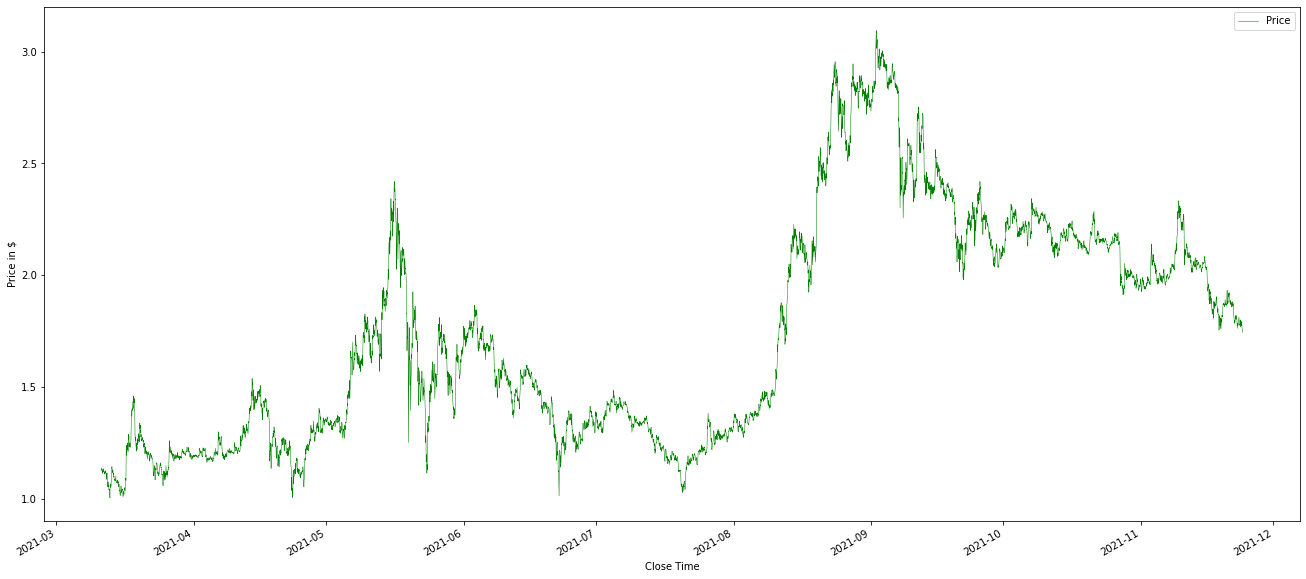

In [ ]:
fig = plt.figure()
fig.set_size_inches(22.5, 10.5)

fig = plt.figure()
fig.set_size_inches(22.5, 10.5)
ax1 = fig.add_subplot(111, ylabel='Price in $')
data["Close"].plot(ax=ax1, color='g', lw=.5)
plt.legend(["Price"])

plt.show()

Main function for gathering all models

In [18]:
import time
ticker = tickers[1]
    
possitionsv_arr = []
possitionsr_arr = []
recent_balance = []
verif_balance = []
model_arr = []
columns_arr = []
nr_columns = []

train_data_possitions = data.loc[train_date_start:train_date_end, 'positions']
print("Dates are: ", train_date_start,train_date_end + 
      "\nlength of train data: ", len(train_data_possitions))

recent_data_Close = data.loc[recent_date_start:recent_date_end, 'Close']
verif_data_Close = data.loc[verif_date_start:verif_date_end, 'Close']
data.drop(['positions'], axis=1, inplace=True)

train_data = data.loc[train_date_start:train_date_end, data.columns != 'Close']
recent_data = data.loc[recent_date_start:recent_date_end, data.columns != 'Close']
verif_data = data.loc[verif_date_start:verif_date_end, data.columns != 'Close']

#loop for selecting random columns. Check 2000 different possibilities
for ML_algo in classifiers:
  start_exec = time.time()

  colmns_select = get_random_columns(len(train_data.columns))

  train_data_X = train_data.iloc[:, colmns_select].copy()
  recent_data_X = recent_data.iloc[:, colmns_select].copy()
  verif_data_X = verif_data.iloc[:, colmns_select].copy()

  train_data_X['positions'] = train_data_possitions

  model = train_model(train_data_X, ML_algo, len(colmns_select))

  # calculation for Recent data
  signalsr = pred(model, recent_data_X, recent_data_Close)
  

  # calculation for Verif data
  signals = pred(model, verif_data_X, verif_data_Close)


  if len(signalsr[signalsr['positions'] == 1]) > 10 and \
      len(signals[signals['positions'] == 1]) > 10 :
      # record results
      recent_balance.append(calculate_balance(signalsr) - 100)
      verif_balance.append(calculate_balance(signals) - 100)
      possitionsr_arr.append(len(signalsr[signalsr['positions'] == 1]))
      possitionsv_arr.append(len(signals[signals['positions'] == 1]))
      columns_arr.append(colmns_select)
      model_arr.append(ML_algo)
      nr_columns.append(len(colmns_select))


  #print(ML_algo, "--- %s seconds ---" % (time.time() - start_exec))
df = pd.DataFrame({'pos_ver': possitionsv_arr, 'pos_rec': possitionsr_arr,
                  'verif_balance': verif_balance, 'recent_balance': recent_balance,
                  'columns': columns_arr, 'Model': model_arr, "nr_columns": nr_columns})

df['Result'] = df['verif_balance'] / df['pos_ver'] + df['recent_balance'] / df['pos_rec']
df.dropna(inplace=True)
df.reset_index(inplace=True)

Dates are:  2021-07-01 2021-07-30
length of train data:  720


<Figure size 1620x756 with 0 Axes>

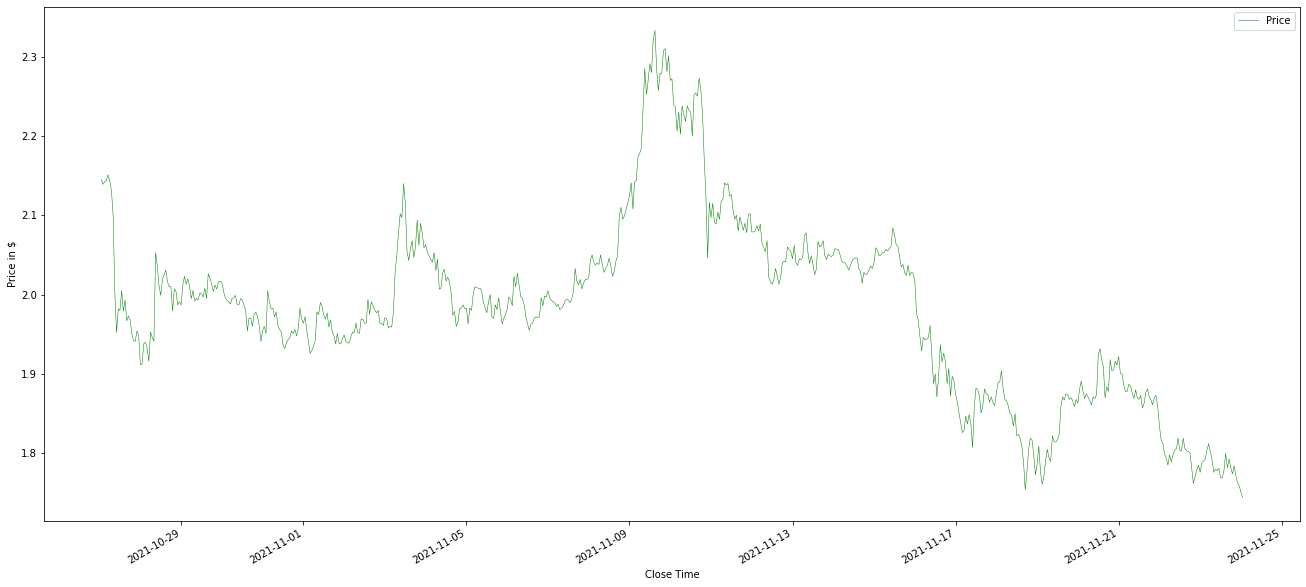

In [ ]:
fig = plt.figure()
fig.set_size_inches(22.5, 10.5)

fig = plt.figure()
fig.set_size_inches(22.5, 10.5)
ax1 = fig.add_subplot(111, ylabel='Price in $')
recent_data_Close.plot(ax=ax1, color='g', lw=.5)
plt.legend(["Price"])

plt.show()

<Figure size 1620x756 with 0 Axes>

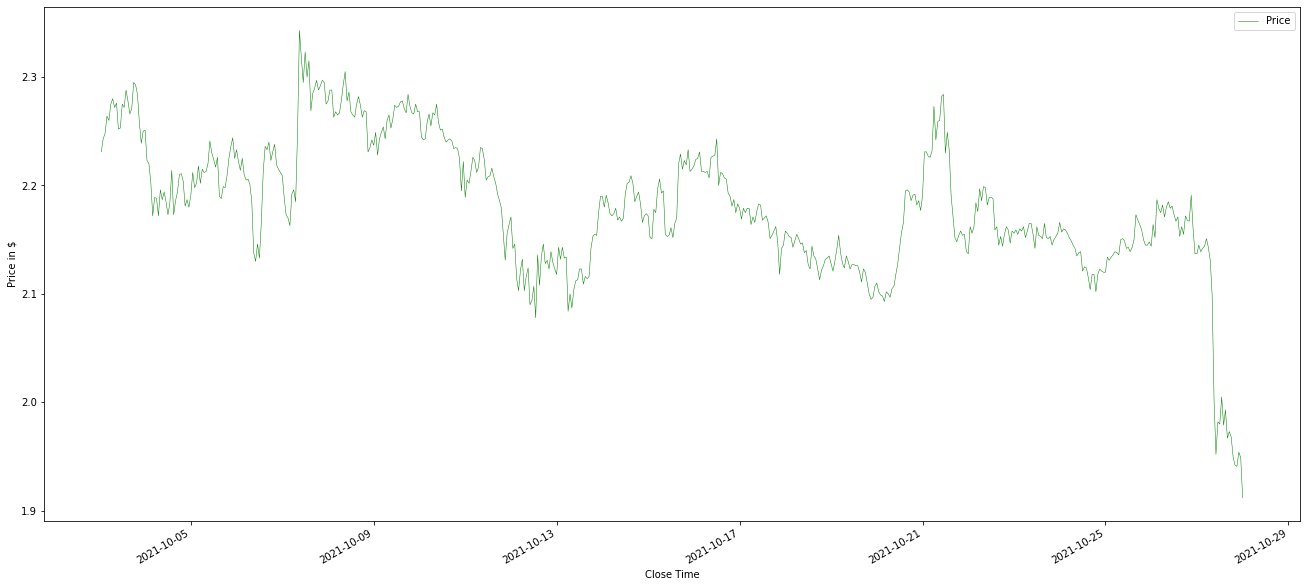

In [ ]:
fig = plt.figure()
fig.set_size_inches(22.5, 10.5)

fig = plt.figure()
fig.set_size_inches(22.5, 10.5)
ax1 = fig.add_subplot(111, ylabel='Price in $')
verif_data_Close.plot(ax=ax1, color='g', lw=.5)
plt.legend(["Price"])

plt.show()

In [19]:
df.sort_values(by=["recent_balance"]).tail(10)

,index,pos_ver,pos_rec,verif_balance,recent_balance,columns,Model,nr_columns,Result
0,0,87,74,-26.64,-19.12,"[1, 2, 3, 4, 8, 13, 14, 15, 16, 17, 19, 20, 22...",KNeighborsClassifier(n_neighbors=2),19,-0.564585
1,1,16,13,3.10,2.85,"[1, 4, 5, 6, 7, 8, 9, 11, 12, 15, 17, 18, 20, ...",LinearDiscriminantAnalysis(),23,0.412981


In [20]:
df.sort_values(by=["verif_balance"]).tail(10)

,index,pos_ver,pos_rec,verif_balance,recent_balance,columns,Model,nr_columns,Result
0,0,87,74,-26.64,-19.12,"[1, 2, 3, 4, 8, 13, 14, 15, 16, 17, 19, 20, 22...",KNeighborsClassifier(n_neighbors=2),19,-0.564585
1,1,16,13,3.10,2.85,"[1, 4, 5, 6, 7, 8, 9, 11, 12, 15, 17, 18, 20, ...",LinearDiscriminantAnalysis(),23,0.412981


In [21]:
# get best line
best_result = max(df.sort_values(by=["verif_balance"]).tail(5).Result.max(),
df.sort_values(by=["recent_balance"]).tail(5).Result.max())
index = df.loc[df['Result'] == best_result].index
#index = [1131]
df.iloc[index,:]

,index,pos_ver,pos_rec,verif_balance,recent_balance,columns,Model,nr_columns,Result
1,1,16,13,3.1,2.85,"[1, 4, 5, 6, 7, 8, 9, 11, 12, 15, 17, 18, 20, ...",LinearDiscriminantAnalysis(),23,0.412981


Verif on NOW

In [34]:
colmns_select = np.array(df['columns'][index[0]:index[0]+1].values).tolist()[0]
ML_algo =  np.array(df['Model'][index[0]:index[0]+1].values).tolist()[0]

In [ ]:
# btc_data = binance_data('BTCUSDT', now_start_date, now_end_date)
# btc_data = btc_data[['Close']]
# btc_data.dropna(axis=0, inplace=True)

# eth_data = binance_data('ETHUSDT', now_start_date, now_end_date)
# eth_data = btc_data[['Close']]
# eth_data.dropna(axis=0, inplace=True)

In [ ]:
#df_with_changes_new = market_change(now_start_date, now_end_date, online=True)

In [35]:
#ticker = 'BNB'
#old_data = get_raw_data('2021-06-01','2022-01-01', ticker, df_with_changes)
print(ML_algo)
market_trend = list()
my_trend = list()
transactions = list()
for ticker in tickers:

    new_data = get_raw_data(now_start_date, now_end_date, ticker)
    
    train_data = data.loc[train_date_start:train_date_end, data.columns != 'Close']
    train_data_X = train_data.iloc[:, colmns_select].copy()
    train_data_X['positions'] = train_data_possitions
    
    model = train_model(train_data_X, ML_algo, len(colmns_select))

    
    latest_data = new_data.loc[now_start_date:now_end_date, new_data.columns != 'Close']
    #latest_data.drop(["short_mavg", "long_mavg"], axis=1, inplace=True)
    latest_data_Close = new_data.loc[now_start_date:now_end_date, 'Close']
    latest_data_positions = new_data.loc[now_start_date:now_end_date, 'positions']
    latest_data_X = latest_data.iloc[:, colmns_select].copy()

    latest_pred = pred(model, latest_data_X, latest_data_Close)

    market_trend.append(100*latest_data_Close[-1]/latest_data_Close[1]-100)
    my_trend.append(calculate_balance(latest_pred) - 100)
    transactions.append(len(latest_pred.loc[latest_pred['positions'] == 1]))
  
    
df1 = pd.DataFrame({'market_trend':market_trend,'my_trend':my_trend,'transactions':transactions})
df1['positions'] = np.where(df1['my_trend'] > df1['market_trend'], 'win', 'loss')
df1['diff'] = np.subtract(df1['my_trend'], df1['market_trend'])
#     if market_trend<my_trend:
#       print(ticker, "WINNER")
#       print("overcome market by", round(my_trend - market_trend,2))
#     else:
#       print(ticker)
#     print("Market trend ", round(market_trend), "%")
#     print("My trend ", round(my_trend,2), "$")
#     print("Transactions ", (len(latest_pred.loc[latest_pred['positions'] == 1])))
#     if len(latest_pred.loc[latest_pred['positions'] == 1]))>10: avr_perform.append(my_trend - market_trend)
# print(np.average(avr_perform))

LinearDiscriminantAnalysis()


In [40]:
df1['ticker'] = tickers

In [43]:
df1

,market_trend,my_trend,transactions,positions,diff,ticker
0,-61.252101,-17.86,95,win,43.392101,ADA
1,-69.756691,-55.58,93,win,14.176691,BEAM
2,-49.804463,0.00,0,win,49.804463,BNB
3,-58.844057,-28.38,90,win,30.464057,BAT
4,-57.563260,0.00,0,win,57.563260,BTC
5,-67.368421,-39.17,87,win,28.198421,COTI
6,-68.735245,-27.31,67,win,41.425245,EOS
7,-67.387923,-24.46,11,win,42.927923,ETH
8,-69.661494,-9.79,17,win,59.871494,SOL
9,-70.715863,-29.58,88,win,41.135863,VET


In [44]:
# this is on how much on avarage i am beating the market in %
df1['diff'].mean()

33.1898340065228

In [45]:
latest_data.columns

Index(['ROC10', 'ROC30', 'ROC50', 'ROC100', 'ROC150', 'MOM10', 'MOM30',
       'MOM50', 'MOM100', 'MOM150', 'RSI10', 'RSI30', 'RSI50', 'RSI100',
       'RSI200', '%K10', '%D10', '%K30', '%D30', '%K50', '%D50', '%K90',
       '%D90', '%K200', '%D200', 'SMA10', 'SMA20', 'SMA55', 'SMA90', 'SMA155',
       'MACD1020', 'MACD2055', 'MACD5590', 'MACD90155', 'BolBands10up',
       'BolBands10down', 'BolBands20up', 'BolBands20down', 'BolBands50up',
       'BolBands50down', 'BolBands100up', 'BolBands100down', 'EMA20', 'EMA100',
       'APO', 'short_mavg', 'long_mavg', 'positions'],
      dtype='object')

In [46]:
balance_arr = calculate_balance(latest_pred, array=True)

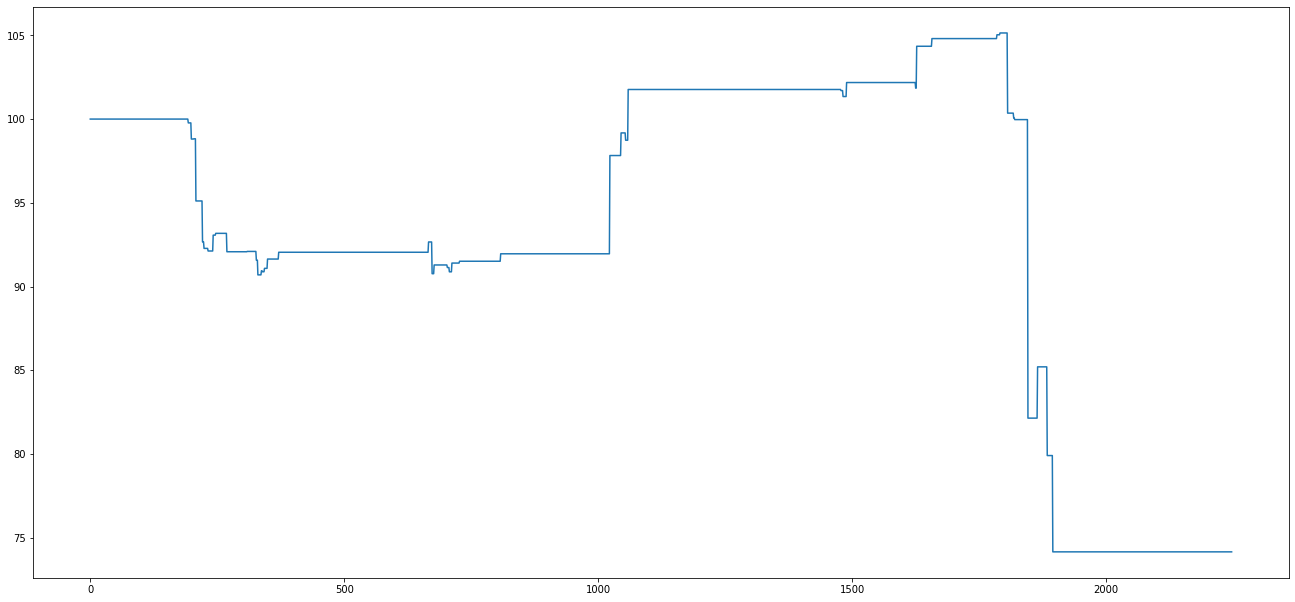

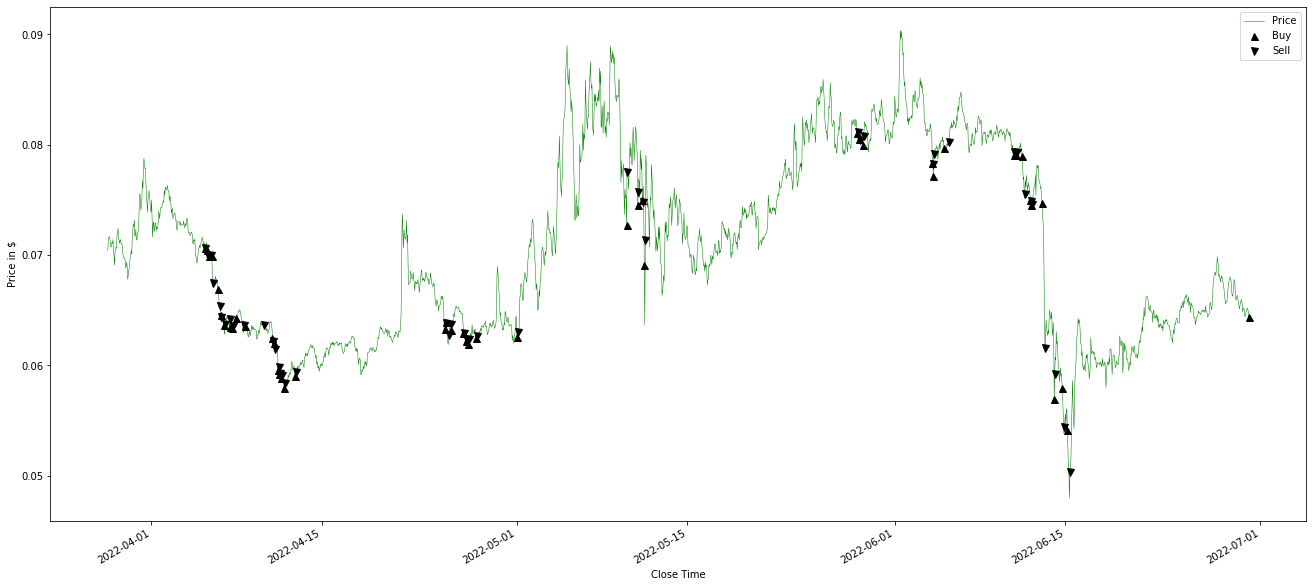

In [47]:
fig = plt.figure()
fig.set_size_inches(22.5, 10.5)
#plt.axhline(y=1000, color='r', linestyle='-')
plt.plot(np.squeeze(balance_arr))
plt.show()

fig = plt.figure()
fig.set_size_inches(22.5, 10.5)
ax1 = fig.add_subplot(111, ylabel='Price in $')
latest_pred["Close"].plot(ax=ax1, color='g', lw=.5)

ax1.plot(latest_pred.loc[latest_pred["positions"]== 1.0].index, latest_pred["Close"][latest_pred["positions"] == 1.0],
         '^', markersize=7, color='k')

ax1.plot(latest_pred.loc[latest_pred["positions"]== -1.0].index, latest_pred["Close"][latest_pred["positions"] == -1.0],
         'v', markersize=7, color='k')


plt.legend(["Price","Buy","Sell"])


plt.show()

# Save selected model

In [ ]:
import pickle
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

with open('drive/My Drive/Colab Notebooks/Models/' + ticker + ' model.pickle','wb') as pickle_out:
     pickle.dump(model , pickle_out)

with open('drive/My Drive/Colab Notebooks/Models/' + ticker + ' columns.pickle','wb') as pickle_out:
     pickle.dump(colmns_select , pickle_out)

# pick_insert = open('drive/My Drive/Colab Notebooks/Model/' + ticker + ' columns.pickle','wb')
# pickle.dump(colmns_select, pick_insert)
# pick_insert.close()

# pick_read = open('drive/My Drive/data.pickle','rb')
# data = pickle.load(pick_read)
# pick_read.close()

Mounted at /content/drive


In [ ]:
tickers = ['BEAM', 'BNB', 'BTC', 'COTI', 'EOS', 'ETH', 'SOL', 'VET', 'XLM', 'XMR',
               'AVAX', 'DOT', 'FTM', 'LINK', 'LTC', 'LUNA', 'MATIC', 'TRX']

In [ ]:
tickers = ['EOS']

In [ ]:
start_date = '2022-03-01'
end_date = '2022-04-27'
df_with_changes_live = market_change(start_date, end_date, online=True)

In [ ]:
for ticker in tickers:
  print(ticker)
  with open('drive/My Drive/Colab Notebooks/Models/' + ticker + ' model.pickle','rb') as pickle_out:
     model = pickle.load(pickle_out)

  with open('drive/My Drive/Colab Notebooks/Models/' + ticker + ' columns.pickle','rb') as pickle_out:
    columns = pickle.load(pickle_out)

  new_data = get_raw_data(start_date, end_date, ticker, df_with_changes_live)

  latest_data = new_data.loc[start_date:end_date, new_data.columns != 'Close']
  latest_data_Close = new_data.loc[start_date:end_date, 'Close']
  latest_data_positions = new_data.loc[start_date:end_date, 'positions']
  latest_data_X = latest_data.iloc[:, columns].copy()

  latest_pred = pred(model, latest_data_X, latest_data_Close)
  # calculation for Recent data
  print("Ratio ", round(100*latest_data_Close[-1]/latest_data_Close[1]-100), "%")
  print("Balance ", round(calculate_balance(latest_pred) - 100,2), "$")
  print("Transactions ", (len(latest_pred.loc[latest_pred['positions'] == 1])))

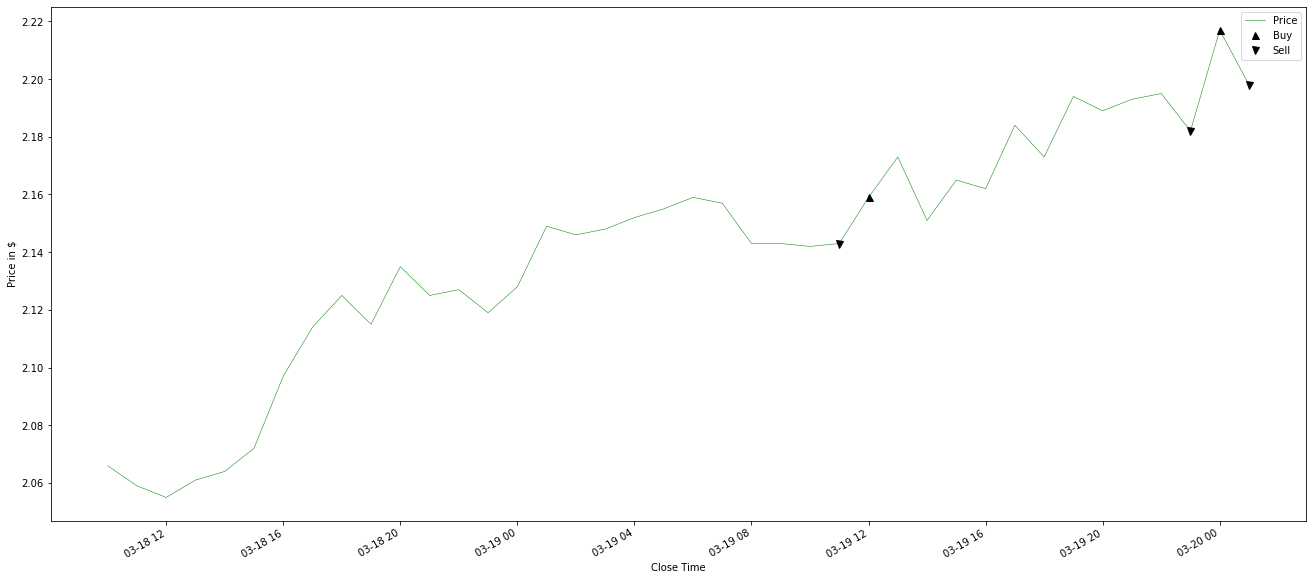

In [ ]:
fig = plt.figure()
fig.set_size_inches(22.5, 10.5)
ax1 = fig.add_subplot(111, ylabel='Price in $')
latest_pred["Close"].plot(ax=ax1, color='g', lw=.5)

ax1.plot(latest_pred.loc[latest_pred["positions"]== 1.0].index, latest_pred["Close"][latest_pred["positions"] == 1.0],
         '^', markersize=7, color='k')

ax1.plot(latest_pred.loc[latest_pred["positions"]== -1.0].index, latest_pred["Close"][latest_pred["positions"] == -1.0],
         'v', markersize=7, color='k')


plt.legend(["Price","Buy","Sell"])


plt.show()

In [ ]:

def sigmoid(x):

    return 1 / (1 + math.exp(-x))


In [ ]:
x = sigmoid(0.9)
x